In [50]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv('spam.csv')

In [52]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [54]:
df.columns = ['category', 'message']

In [55]:
df.columns

Index(['category', 'message'], dtype='object')

In [56]:
df['category'].value_counts()

category
ham     4825
spam     747
Name: count, dtype: int64

In [57]:
df.isnull().sum()

category    0
message     0
dtype: int64

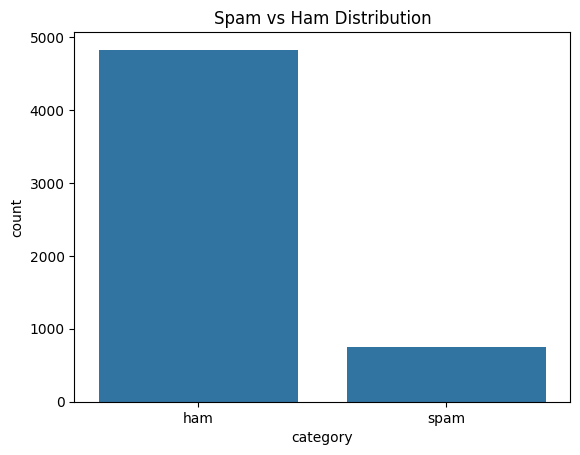

In [58]:
sns.countplot(x='category', data=df)
plt.title('Spam vs Ham Distribution')
plt.show()

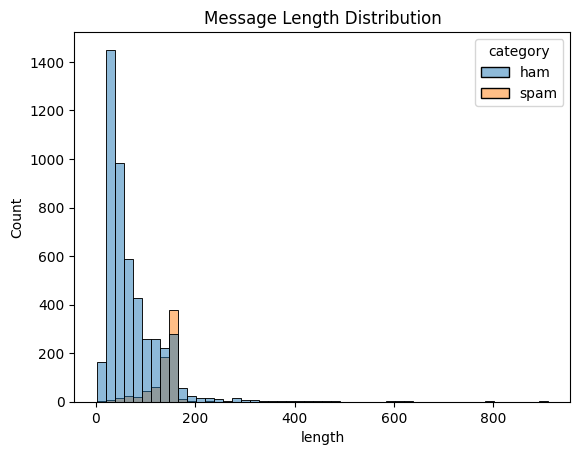

In [59]:
df['length'] = df['message'].apply(len)

sns.histplot(data=df, x='length', hue='category', bins=50)
plt.title('Message Length Distribution')
plt.show()

In [60]:
df['category'] = df['category'].map({'ham':0, 'spam': 1})

In [61]:
df['message'] = df['message'].fillna('')

In [62]:
df.head()

,category,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [63]:
df['message'] = df['message'].apply(lambda x : x.lower())

In [64]:
df.head()

,category,message,length
0,0,"go until jurong point, crazy.. available only ...",111
1,0,ok lar... joking wif u oni...,29
2,1,free entry in 2 a wkly comp to win fa cup fina...,155
3,0,u dun say so early hor... u c already then say...,49
4,0,"nah i don't think he goes to usf, he lives aro...",61


In [65]:
import string

def remove_punc(txt):
    return txt.translate(str.maketrans('','', string.punctuation))

In [66]:
df['message'] = df['message'].apply(remove_punc)

In [67]:
df.head()

,category,message,length
0,0,go until jurong point crazy available only in ...,111
1,0,ok lar joking wif u oni,29
2,1,free entry in 2 a wkly comp to win fa cup fina...,155
3,0,u dun say so early hor u c already then say,49
4,0,nah i dont think he goes to usf he lives aroun...,61


In [68]:
def remove_numbers(txt):
    new = ""
    for i in txt:
        if not i.isdigit():
            new = new + i
    return new

df['message'] = df['message'].apply(remove_numbers)

In [69]:
df.head()

,category,message,length
0,0,go until jurong point crazy available only in ...,111
1,0,ok lar joking wif u oni,29
2,1,free entry in a wkly comp to win fa cup final...,155
3,0,u dun say so early hor u c already then say,49
4,0,nah i dont think he goes to usf he lives aroun...,61


In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [71]:
vectorizer = TfidfVectorizer()

# X = vectorizer.fit_transform(df['message'])
# y = df['category']
X= df['message']
y = df['category']
X = vectorizer.fit_transform(X)

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [74]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [75]:
y_pred_NB = model.predict(X_test)

In [76]:
print("Accuracy ", accuracy_score(y_test, y_pred_NB))
print(classification_report(y_test, y_pred_NB))      

Accuracy  0.9560538116591928
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.67      0.80       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [79]:
y_pred_RF = model.predict(X_test)

In [80]:
print("Accuracy ", accuracy_score(y_test, y_pred_RF))
print(classification_report(y_test, y_pred_RF))

Accuracy  0.9560538116591928
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.67      0.80       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [81]:
from sklearn.linear_model import LogisticRegression

In [82]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [83]:
y_pred_LR = model.predict(X_test)

In [84]:
print("Accuracy:", accuracy_score(y_test, y_pred_LR))
print(classification_report(y_test, y_pred_LR))

Accuracy: 0.9560538116591928
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.67      0.80       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [85]:
def check_spam(text):
    vec = vectorizer.transform([text])
    result = model.predict(vec)

    if result == 1:
        return "spam"
    else:
        return "Not spam"
# print(check_spam('Hey Bro, kal milte hain'))
# print(check_spam('Congratulations! You won RS.5000 click'))

In [86]:
print(check_spam('Hey Bro, kal milte hain'))

Not spam


In [87]:
print(check_spam('Congratulations! You won RS.5000 lakh'))

spam


In [88]:
# import joblib
# joblib.dump(model, 'NB_spam.pkl')
# joblib.dump(vectorizer, 'vectorizer_spam.pkl')

['vectorizer_spam.pkl']